# Agent 2: Aging Expert (절연열화 전문가)

In [1]:
# Aging(절연열화) Expert Graph Init
import sys
import os
from pathlib import Path
import json
import time

# 프로젝트 루트 경로 설정
project_root = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
sys.path.insert(0, str(project_root))

# 환경 변수 로드
from dotenv import load_dotenv
load_dotenv(project_root / ".env")

print(f"✓ 프로젝트 루트: {project_root}")

# 2. 테스트 이미지 준비
from src.utils import find_data_directory
from src.tools.experts.expert_utils import save_bytes_to_temp_file
from src.tools.experts.expert_utils import call_gemini_text, parse_json_response

try:
    data_dir = find_data_directory()
    # 테스트할 이미지 파일명 (필요시 변경)
    test_image_name = "IMG_8113.jpg" 
    test_image_path = Path(data_dir) / test_image_name
    
    if not test_image_path.exists():
        image_files = list(Path(data_dir).glob("*.png")) + list(Path(data_dir).glob("*.jpg"))
        if image_files:
            test_image_path = image_files[0]
            print(f"⚠️ 지정된 이미지를 찾을 수 없어 {test_image_path.name}을 사용합니다.")
        else:
            raise FileNotFoundError("테스트할 이미지가 없습니다.")
            
    print(f"✓ 테스트 이미지: {test_image_path}")
    
    with open(test_image_path, 'rb') as f:
        image_data = f.read()
    temp_image_path = save_bytes_to_temp_file(image_data)
    print(f"✓ 임시 이미지 경로: {temp_image_path}")
    
except Exception as e:
    print(f"❌ 오류: {e}")

# 3. 그래프 빌드 및 상태 초기화 (실행 전 필수)
from src.graphs.aging_expert_graph import build_aging_expert_graph
from src.nodes.aging_nodes import AgingExpertState

print("✓ 그래프 빌드 및 초기 상태 생성 중...")

# AgingExpertState 정의에 맞춘 초기화
initial_state = AgingExpertState(
    messages=[],
    image_path=temp_image_path,
    hotspots=[],
    hotspot_queue=None,
    analysis_results=[],
    # Loop 변수 초기화
    current_hotspot=None,
    detector_result=None,
    roi_image_path=None,
    connection_type=None,
    specialist_result=None, # Aging Expert는 통합 필드를 사용 (terminal/splice 등의 구분 없음)
    verdict_report=None,
    verdict_confidence=None,
    verdict_result=None
)

graph = build_aging_expert_graph()
print("✓ 완료: initial_state 및 graph 객체 준비됨")

✓ 프로젝트 루트: c:\Users\user\Documents\Project\P_04_Scope
✓ 테스트 이미지: c:\Users\user\Documents\Project\P_04_Scope\data\IMG_8113.jpg
✓ 임시 이미지 경로: C:\Users\user\AppData\Local\Temp\tmpifokxpep.jpg


c:\Users\user\Documents\Project\P_04_Scope\venv\Lib\site-packages\torchvision\transforms\functional_tensor.py:5: UserWarning: The torchvision.transforms.functional_tensor module is deprecated in 0.15 and will be **removed in 0.17**. Please don't rely on it. You probably just need to use APIs in torchvision.transforms.functional or in torchvision.transforms.v2.functional.
  warnings.warn(


✓ 그래프 빌드 및 초기 상태 생성 중...
✓ 완료: initial_state 및 graph 객체 준비됨


Multi-Hotspot Loop 전체 실행

📡 [Aging/Hotspot Detector] 다중 발화 지점 탐색 시작... (이미지: C:\Users\user\AppData\Local\Temp\tmpifokxpep.jpg)
📋 [Hotspot Detector] Finish reason: FinishReason.STOP

💭 [Hotspot Detector] 모델 응답 텍스트:
------------------------------------------------------------
📝 [Thinking 과정 (SDK Extracted)]:
**Forensic Fire Investigation: Analysis of Electrical Component Image**

Okay, here's how I'm approaching this image analysis. My focus is entirely on objective observation, using the established principles and terminology of fire investigation. No subjective interpretations, no leaps to causal inferences. Strictly adhering to the given constraints. My task is to meticulously describe what I *see*, not what I *think* happened. The final output must be in the correct JSON format.

First, I'm establishing the global context. This is an image of electrical wiring and a terminal block component. They're placed on a forensic grid mat, which is a key element for scale and spatial reference

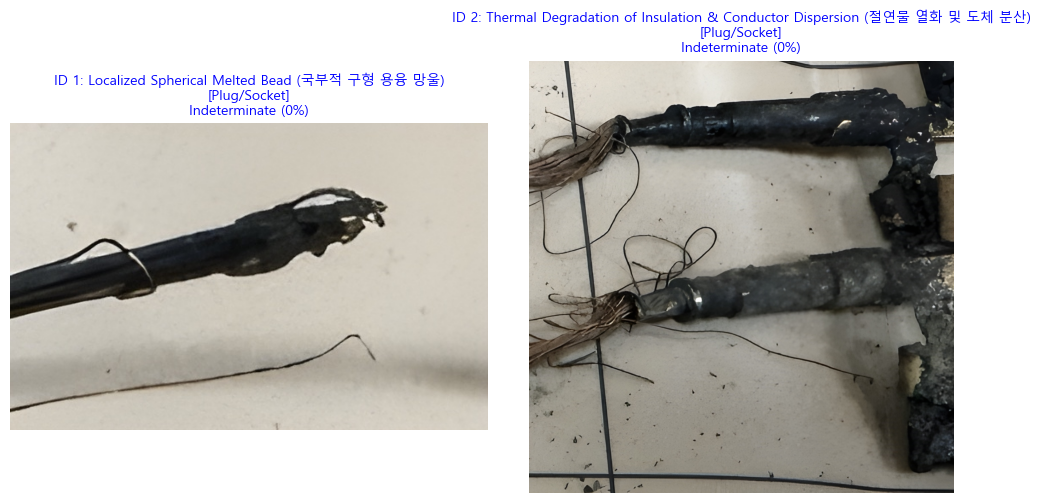

In [2]:
# Aging Expert Graph Run
print("=" * 60)
print("Multi-Hotspot Loop 전체 실행")
print("=" * 60)

start_time = time.time()
try:
    # Recursion Limit을 넉넉히 주어야 Loop가 돕니다.
    final_state = graph.invoke(initial_state, config={"recursion_limit": 50})
    elapsed = time.time() - start_time
    
    print(f"\n✓ 전체 실행 완료 (소요시간: {elapsed:.2f}초)")
    
    # 결과 출력
    print("\n📊 최종 리포트 (Verdict):")
    print("-" * 60)
    print(final_state.get("verdict_report", "결과 없음"))
    
    # Hotspots 확인
    hotspots = final_state.get("hotspots", [])
    print(f"\n🔍 발견된 Hotspots: {len(hotspots)}개")
    for h in hotspots:
        print(f"   - ID {h.get('id')}: {h.get('damage_type')} ({h.get('severity_score')}점)")
    
    # 디버깅: final_state의 전체 키 확인
    print(f"\n[Debug] Final State Keys: {list(final_state.keys())}")

    # 분석된 결과들 내용 확인 (JSON 출력)
    print("\n📄 [Detailed Analysis Results]")
    print("-" * 60)
    analysis_results = final_state.get("analysis_results", [])
    print(json.dumps(analysis_results, indent=2, ensure_ascii=False))

    # 결과 시각화 (Processed Images)
    print("\n📷 [Processed Images Visualization]")
    print("-" * 60)
    
    from PIL import Image
    import matplotlib.pyplot as plt
    import matplotlib.font_manager as fm
    import os
    
    # 한글 폰트 설정 (Windows)
    try:
        # Windows에서 사용 가능한 한글 폰트 찾기
        font_list = ['Malgun Gothic', 'NanumGothic', 'NanumBarunGothic', 'Gulim', 'Batang']
        font_found = None
        for font_name in font_list:
            try:
                font_path = fm.findfont(fm.FontProperties(family=font_name))
                if font_path:
                    plt.rcParams['font.family'] = font_name
                    font_found = font_name
                    break
            except:
                continue
        
        if font_found:
            print(f"✓ 한글 폰트 설정: {font_found}")
        else:
            # 폰트를 찾지 못한 경우 경고만 출력하고 계속 진행
            print("⚠️ 한글 폰트를 찾을 수 없습니다. 한글이 제대로 표시되지 않을 수 있습니다.")
    except Exception as e:
        print(f"⚠️ 폰트 설정 중 오류: {e}")
    
    if not analysis_results:
        print("No analyzed images found.")
    else:
        num_images = len(analysis_results)
        if num_images > 0:
            # 서브플롯 크기 및 배열 설정
            cols = min(num_images, 5)
            rows = (num_images - 1) // cols + 1
            fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
            
            # axes가 단일 객체이거나 1차원 배열일 경우 처리
            if num_images == 1:
                axes = [axes]
            elif rows > 1:
                axes = axes.flatten()
            
            # 빈 서브플롯 숨기기
            if hasattr(axes, '__len__') and len(axes) > num_images:
                for ax in axes[num_images:]:
                    ax.axis('off')
            
            for idx, res in enumerate(analysis_results):
                # Data Extraction optimized for Aging Expert
                h_info = res.get('hotspot_info', {})
                hotspot_id = h_info.get('id', '?')
                feature = h_info.get('damage_type', 'Unknown')
                conn_type = res.get('connection_type', 'N/A')
                
                roi_path = res.get('roi_image_path')
                
                # Specialist Result Extraction
                # Aging Expert는 'specialist_result' 필드를 사용
                spec_res = res.get('specialist_result', {}) or {}
                
                verdict = spec_res.get('verdict', 'Indeterminate')
                # 긴 Verdict 문자열 줄임 처리
                if len(verdict) > 20: 
                    verdict = verdict.split('(')[0].strip() # 괄호 앞부분만 사용
                    
                conf = spec_res.get('confidence', 0)
                
                ax = axes[idx]
                
                if roi_path and os.path.exists(roi_path):
                    try:
                        img = Image.open(roi_path)
                        ax.imshow(img)
                        # Title 구성: ID, 판정 결과, 신뢰도
                        title_text = f"ID {hotspot_id}: {feature}\n[{conn_type}]\n{verdict} ({conf}%)"
                            
                        # Aging Expert 판정에 따른 색상 (예: Electrical Arc -> Red, Thermal -> Orange, Cut -> Blue)
                        if "Arc" in verdict or "Short" in verdict or "Electrical" in verdict or "Tracking" in verdict:
                             title_color = 'red'
                        elif "Thermal" in verdict or "Heat" in verdict or "Melt" in verdict:
                             title_color = 'orange'
                        else:
                             title_color = 'blue'

                        ax.set_title(title_text, fontsize=10, color=title_color)
                    except Exception as e:
                        ax.text(0.5, 0.5, "Error Loading", ha='center')
                        print(f"Error loading image {roi_path}: {e}")
                else:
                    ax.text(0.5, 0.5, "Image Not Found", ha='center')
                    ax.set_title(f"ID {hotspot_id}")
                    
                ax.axis('off')
            
            plt.tight_layout()
            plt.show()

except Exception as e:
    print(f"❌ 실행 중 오류: {e}")
    import traceback
    traceback.print_exc()